In [20]:
from pathlib import Path

import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt

import geopandas as gpd
import contextily as ctx


# Goal of this notebook
Compute the stationary distribution of the bike-sharing station network that was built in the previous notebook.

In [21]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

padding = 2800

In [22]:
edges_df = pd.read_parquet(DATA_DIR / "edges_df.parquet")
stations_df = pd.read_parquet(DATA_DIR / "stations_df.parquet")

edges_df.head()

,start_station_id,start_station_name,end_station_id,end_station_name,weight
0,959,"Milroy Walk, South Bank",959.0,"Milroy Walk, South Bank",296
1,959,"Milroy Walk, South Bank",960.0,"Hop Exchange, The Borough",622
2,959,"Milroy Walk, South Bank",961.0,"Union Street, The Borough",159
3,959,"Milroy Walk, South Bank",962.0,"Stamford Street, South Bank",221
4,959,"Milroy Walk, South Bank",963.0,"Bankside Mix, Bankside",231


In [23]:
stations_df.head()

,station_id,station_name,lat,lon
0,1108.0,"North Wharf Road, Paddington",51.518623,-0.176603
1,3447.0,"Gloucester Road (North), Kensington",51.497925,-0.183835
2,1090.0,"Warren Street Station, Euston",51.524438,-0.138019
3,200058.0,"Northdown Street, King's Cross",51.531066,-0.119340
4,1052.0,"Soho Square , Soho",51.515631,-0.132329


In [24]:
graph = nx.from_pandas_edgelist(
    edges_df,
    source="start_station_name",
    target="end_station_name",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

### Create a dictionary to store name of the station and its geographic coordinates (longitude and latitude)


In [25]:
# positions = {
#    "Waterloo Station": (-0.113, 51.503),
#    "Hyde Park Corner": (-0.152, 51.502),
#    ...
#}

positions = {}

for _, row in stations_df.iterrows():

    positions[row["station_name"]] = (
        row["lon"],
        row["lat"]
    )

### Stations have specific IDs, lets create a mapping from station_id to index


In [26]:
station_to_index = {
    station_id: idx
    for idx, station_id in enumerate(
        sorted(stations_df["station_id"].unique())
    )
}

print(station_to_index)

{np.float64(959.0): 0, np.float64(960.0): 1, np.float64(961.0): 2, np.float64(962.0): 3, np.float64(963.0): 4, np.float64(964.0): 5, np.float64(965.0): 6, np.float64(966.0): 7, np.float64(967.0): 8, np.float64(968.0): 9, np.float64(969.0): 10, np.float64(970.0): 11, np.float64(971.0): 12, np.float64(972.0): 13, np.float64(973.0): 14, np.float64(974.0): 15, np.float64(975.0): 16, np.float64(976.0): 17, np.float64(978.0): 18, np.float64(979.0): 19, np.float64(980.0): 20, np.float64(981.0): 21, np.float64(982.0): 22, np.float64(983.0): 23, np.float64(984.0): 24, np.float64(985.0): 25, np.float64(986.0): 26, np.float64(988.0): 27, np.float64(989.0): 28, np.float64(990.0): 29, np.float64(991.0): 30, np.float64(992.0): 31, np.float64(993.0): 32, np.float64(994.0): 33, np.float64(995.0): 34, np.float64(996.0): 35, np.float64(997.0): 36, np.float64(998.0): 37, np.float64(999.0): 38, np.float64(1000.0): 39, np.float64(1001.0): 40, np.float64(1002.0): 41, np.float64(1003.0): 42, np.float64(1004.

In [27]:
index_to_station = {
    idx: station_id
    for station_id, idx in station_to_index.items()
}

print(index_to_station)

{0: np.float64(959.0), 1: np.float64(960.0), 2: np.float64(961.0), 3: np.float64(962.0), 4: np.float64(963.0), 5: np.float64(964.0), 6: np.float64(965.0), 7: np.float64(966.0), 8: np.float64(967.0), 9: np.float64(968.0), 10: np.float64(969.0), 11: np.float64(970.0), 12: np.float64(971.0), 13: np.float64(972.0), 14: np.float64(973.0), 15: np.float64(974.0), 16: np.float64(975.0), 17: np.float64(976.0), 18: np.float64(978.0), 19: np.float64(979.0), 20: np.float64(980.0), 21: np.float64(981.0), 22: np.float64(982.0), 23: np.float64(983.0), 24: np.float64(984.0), 25: np.float64(985.0), 26: np.float64(986.0), 27: np.float64(988.0), 28: np.float64(989.0), 29: np.float64(990.0), 30: np.float64(991.0), 31: np.float64(992.0), 32: np.float64(993.0), 33: np.float64(994.0), 34: np.float64(995.0), 35: np.float64(996.0), 36: np.float64(997.0), 37: np.float64(998.0), 38: np.float64(999.0), 39: np.float64(1000.0), 40: np.float64(1001.0), 41: np.float64(1002.0), 42: np.float64(1003.0), 43: np.float64(1

## Stationary distribution calculation

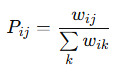

### Construction of the weight matrix

In [28]:
N = len(stations_df["station_id"].unique())

wij_matrix = np.zeros((N, N))


for _, row in edges_df.iterrows():

        start_station = row["start_station_id"]
        end_station = row["end_station_id"]
        weight = row["weight"]

        i = station_to_index[start_station]
        j = station_to_index[end_station]


        wij_matrix[i][j] = weight

wij_matrix.shape

(801, 801)

### Total outgoing traffic from each station


In [29]:
wik_sum = wij_matrix.sum(axis=1)
wik_sum.shape

(801,)

### Reshape wik_sum to be a column vector instead of a 1D array to perform matrix division correctly


In [30]:
wik_sum = wik_sum.reshape((-1, 1))
wik_sum.shape

(801, 1)

### Finally Pij matrix

In [31]:
Pij_matrix = wij_matrix / wik_sum

print(Pij_matrix)

[[0.01525695 0.0320602  0.00819545 ... 0.00113396 0.00762847 0.00257719]
 [0.00712542 0.02028331 0.00475501 ... 0.00265429 0.00547891 0.00202975]
 [0.005588   0.02038864 0.0233085  ... 0.00045308 0.00463149 0.00372533]
 ...
 [0.00170948 0.00859122 0.00048216 ... 0.0216972  0.00219164 0.00105199]
 [0.00186766 0.02114461 0.00296825 ... 0.00243463 0.06723586 0.01784285]
 [0.00248139 0.0083871  0.00431762 ... 0.00143921 0.02024814 0.03473945]]


### Since Pij_matrix is a transition probability matrix, each row should sum to 1


In [32]:
Pij_matrix.sum(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

### Stationary distribution computation using the power method

At the beginning, all stations are assigned the same probability equal to 1/N.

In [33]:
p_t0_matrix = np.zeros((1, N))
p_t0_matrix[0, :] = 1/N
print(p_t0_matrix)

[[0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.

### Power method iterations

In [34]:
p_t1_matrix = np.zeros((1, N))

diff = abs(p_t1_matrix - p_t0_matrix). sum()
iteration = 0

while diff > 1e-10:
    p_t1_matrix = p_t0_matrix @ Pij_matrix
    diff = abs(p_t1_matrix - p_t0_matrix). sum()
    p_t0_matrix = p_t1_matrix
    iteration += 1

print(iteration)

stationary_distribution = p_t1_matrix


78


### The stationary distribution should sum to 1

In [35]:
print(stationary_distribution.sum().round(5))

1.0


In [36]:
print(stationary_distribution)

[[1.19694307e-03 5.20180163e-03 1.19495217e-03 1.34156917e-03
  1.67731024e-03 1.74637100e-03 1.33896265e-03 1.25083590e-03
  1.16555550e-03 2.44765210e-03 1.18462916e-03 1.01269414e-03
  1.62957351e-03 1.77936267e-03 2.85803667e-03 1.79672063e-03
  1.34723658e-03 7.30692565e-04 1.57601533e-03 1.29073356e-03
  2.43259706e-03 1.71921551e-03 3.24075180e-03 7.56090953e-04
  3.17781444e-03 1.52455422e-03 7.37198256e-04 1.38516439e-03
  9.42258326e-04 7.97599133e-04 3.00247633e-03 6.67856204e-04
  6.71858033e-04 1.65152870e-03 3.27034337e-03 1.24705741e-03
  1.70114616e-03 1.36590774e-03 3.82978978e-03 2.39097427e-03
  8.55440066e-04 1.29155351e-03 1.38425055e-03 1.40728181e-03
  8.56707247e-04 9.14236672e-04 2.47295596e-03 1.79769457e-03
  1.43848336e-03 1.16354013e-03 4.17912381e-03 9.45743310e-04
  8.15039233e-04 9.61768417e-04 1.04957531e-03 1.60303114e-03
  1.53987441e-03 8.90764122e-04 1.51141748e-03 1.62451931e-03
  5.85529009e-04 8.92418322e-04 1.28886000e-03 9.04709259e-04
  1.2330

### 10 most important stations

In [37]:
sorted_indices = np.argsort(stationary_distribution[0])[::-1]
sorted_probs = stationary_distribution[0][sorted_indices]

top_10_stations = sorted_indices[:10]
top_10_probs = sorted_probs[:10]

for idx, prob in zip(top_10_stations, top_10_probs):

    station_id = index_to_station[idx]

    station_name = stations_df[stations_df["station_id"] == station_id]["station_name"].values[0]

    print(station_name)


Waterloo Station 3, Waterloo
Hyde Park Corner, Hyde Park
Hop Exchange, The Borough
Waterloo Station 1, Waterloo
Brushfield Street, Liverpool Street
Wormwood Street, Liverpool Street
St. James's Square, St. James's
Duke Street Hill, London Bridge
Albert Gate, Hyde Park
Exhibition Road, Knightsbridge


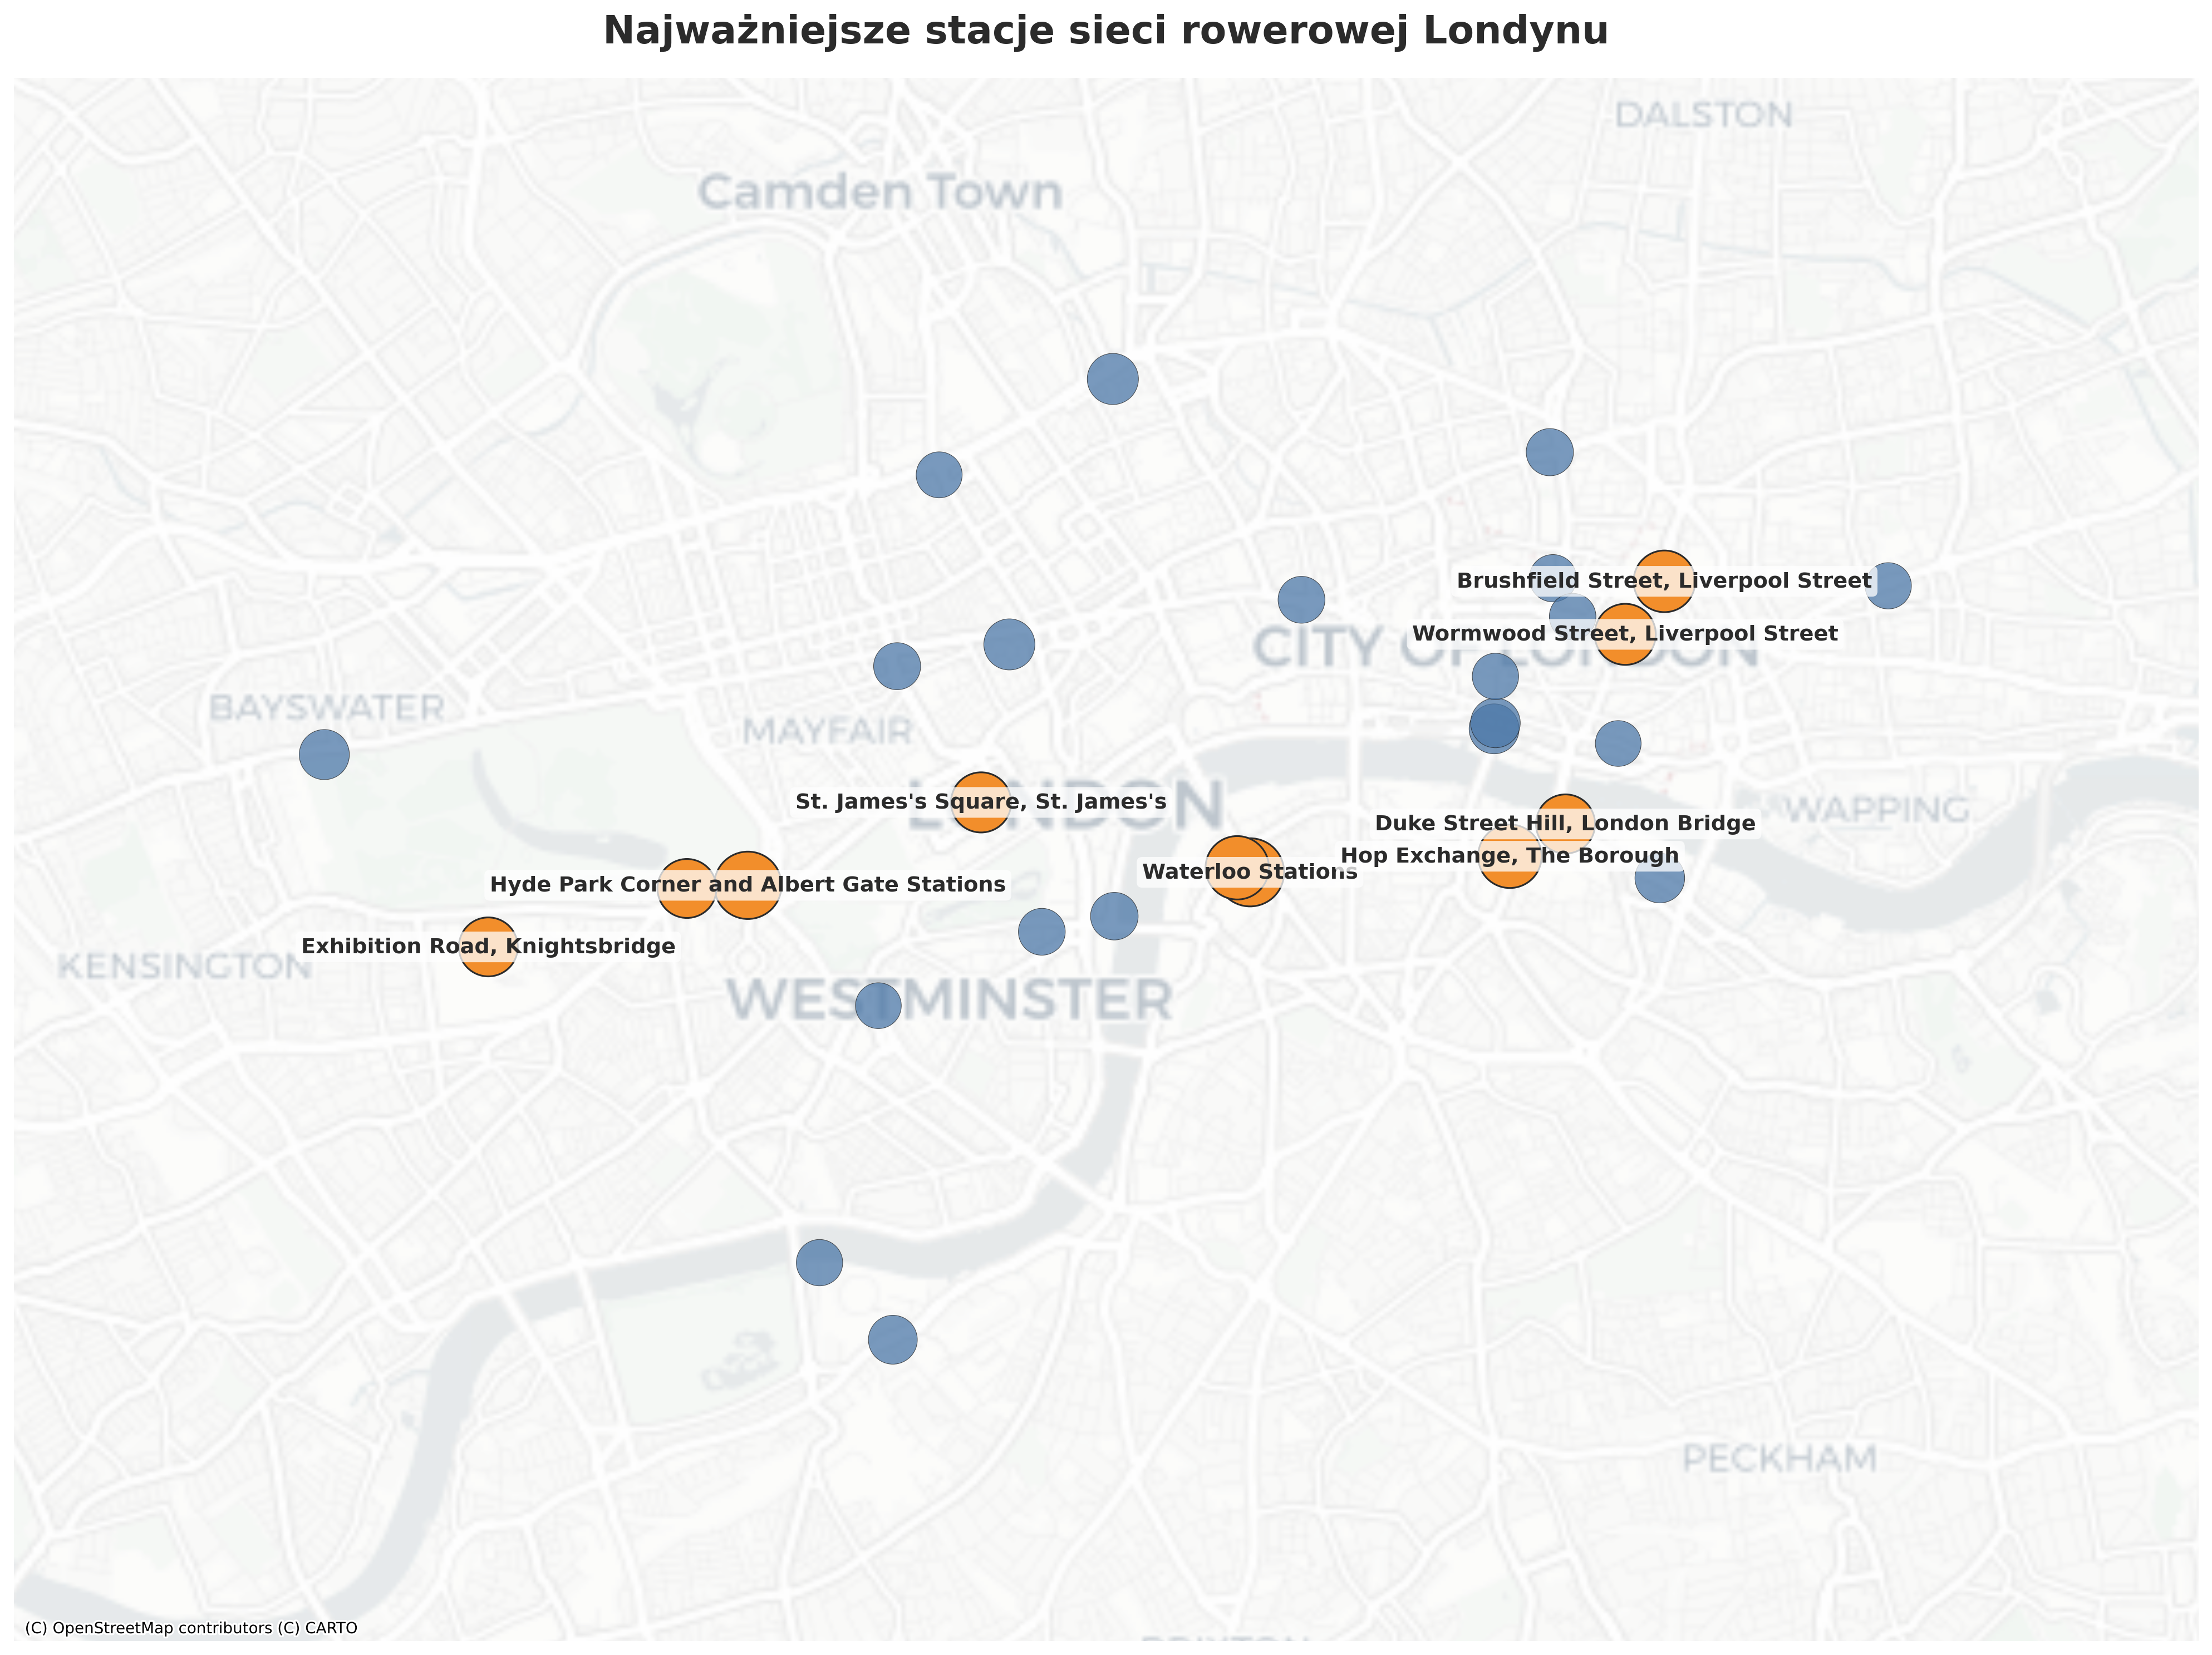

In [38]:
# ---------- Top 30 stations ----------

top_30_indices = sorted_indices[:30]

top_30_names = []

for idx in top_30_indices:

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    top_30_names.append(station_name)


# ---------- Top 10 stations ----------

top_10_names = []

for idx in top_10_stations:

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    top_10_names.append(station_name)


# ---------- Filtering strongest edges ----------

min_weight = 400

filtered_edges_df = edges_df[
    (edges_df["start_station_name"] != edges_df["end_station_name"]) &
    (edges_df["weight"] >= min_weight)
].copy()


# ---------- Building filtered graph ----------

filtered_graph = nx.from_pandas_edgelist(
    filtered_edges_df,
    source="start_station_name",
    target="end_station_name",
    edge_attr="weight",
    create_using=nx.DiGraph()
)


# ---------- GeoDataFrame ----------

stations_df["lat"] = stations_df["lat"].astype(float)
stations_df["lon"] = stations_df["lon"].astype(float)

geo_df = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(
        stations_df["lon"],
        stations_df["lat"]
    ),
    crs="EPSG:4326"
)

geo_df = geo_df.to_crs(epsg=3857)


# ---------- Positions in EPSG:3857 ----------

positions_3857 = {}

for _, row in geo_df.iterrows():

    positions_3857[row["station_name"]] = (
        row.geometry.x,
        row.geometry.y
    )


# ---------- Stationary distribution dictionary ----------

stationary_dict = {}

for idx, probability in enumerate(stationary_distribution[0]):

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    stationary_dict[station_name] = probability


# ---------- Node sizes proportional to stationary distribution ----------

top_30_node_sizes = [
    200 + 120000 * stationary_dict[node]
    for node in top_30_names
]

top_10_node_sizes = [
    300 + 150000 * stationary_dict[node]
    for node in top_10_names
]


# ---------- Labels ----------

labels_to_skip = [
    "Waterloo Station 1, Waterloo",
    "Albert Gate, Hyde Park"
]

labels = {}

for node in top_10_names:

    if node in labels_to_skip:
        continue

    elif node == "Waterloo Station 3, Waterloo":
        labels[node] = "Waterloo Stations"

    elif node == "Hyde Park Corner, Hyde Park":
        labels[node] = "Hyde Park Corner and Albert Gate Stations"

    else:
        labels[node] = node


# ---------- Plot style ----------

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.titleweight"] = "bold"


# ---------- Drawing ----------

fig, ax = plt.subplots(figsize=(16, 12), dpi=250)


# Top 30 stations

nx.draw_networkx_nodes(
    filtered_graph,
    positions_3857,
    nodelist=top_30_names,
    node_size=top_30_node_sizes,
    node_color="#4C78A8",
    alpha=0.75,
    edgecolors="#1f1f1f",
    linewidths=0.3,
    ax=ax
)


# Top 10 stations highlighted

nx.draw_networkx_nodes(
    filtered_graph,
    positions_3857,
    nodelist=top_10_names,
    node_size=top_10_node_sizes,
    node_color="#F28E2B",
    alpha=1.0,
    edgecolors="#2b2b2b",
    linewidths=0.9,
    ax=ax
)


# Labels for selected top 10 stations

text_items = nx.draw_networkx_labels(
    filtered_graph,
    positions_3857,
    labels=labels,
    font_size=11,
    font_weight="bold",
    font_color="#2b2b2b",
    font_family="DejaVu Sans",
    ax=ax
)

for _, text in text_items.items():

    text.set_bbox(
        dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.25"
        )
    )


# ---------- Map extent ----------

x_values = [
    positions_3857[node][0]
    for node in top_30_names
]

y_values = [
    positions_3857[node][1]
    for node in top_30_names
]

ax.set_xlim(
    min(x_values) - padding,
    max(x_values) + padding
)

ax.set_ylim(
    min(y_values) - padding,
    max(y_values) + padding
)


# ---------- Basemap ----------

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

for image in ax.get_images():
    image.set_alpha(0.58)


# ---------- Title ----------

ax.set_title(
    "Najważniejsze stacje sieci rowerowej Londynu",
    color="#2b2b2b",
    pad=18
)

plt.axis("off")
plt.tight_layout()
plt.show()